<a href="https://colab.research.google.com/github/sakshi-nandgude/Hotel-Booking-Analysis/blob/main/Hotel-Booking-Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

2. Description of Dataset

In [ ]:
#2-1: loads the dataset
df=pd.read_csv('/content/hotel_bookings 2 (1).csv')

In [ ]:
#2-2: returns the first 5 rows
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,1/7/2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,1/7/2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2/7/2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2/7/2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,3/7/2015


In [ ]:
#2-3: returns the last 5 rows
df.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,6/9/2017
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,7/9/2017
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,7/9/2017
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,7/9/2017
119389,City Hotel,0,205,2017,August,35,29,2,7,2,...,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,7/9/2017


In [ ]:
#2-4: returns the number of rows and columns
df.shape

(119390, 32)

In [ ]:
#2-5: returns the list of column names
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [ ]:
#2-6: returns the data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
#2-7: gets the summary statistics for numerical variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [ ]:
#2-8: gets the summary statistics for categorical variables
df.describe(include='object').T

,count,unique,top,freq
hotel,119390,2,City Hotel,79330
arrival_date_month,119390,12,August,13877
meal,119390,5,BB,92310
country,118902,177,PRT,48590
market_segment,119390,8,Online TA,56477
distribution_channel,119390,5,TA/TO,97870
reserved_room_type,119390,10,A,85994
assigned_room_type,119390,12,A,74053
deposit_type,119390,3,No Deposit,104641
customer_type,119390,4,Transient,89613


3. Initial Data Preparation

In [ ]:
#2-9: sees if there are null in each column and counts it
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [ ]:
#3-1 fills missing values
df['children'] = df['children'].fillna(0)
df['country'] = df['country'].fillna('Unknown')

In [ ]:
#3-2 removes columns which have alot of null values
df.drop(['company','agent'],axis=1, inplace=True)

In [ ]:
#3-3: verifies the changes made before
print(df.isnull().sum().sum())

0


In [ ]:
#3-4: converts float values in int when needed
df['children'] = df['children'].astype(int)
df['lead_time'] = df['lead_time'].astype(int)

In [ ]:
#3-5: verifies the changes made before
print(df.dtypes)

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                            int64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
days_in_waiting_list              

In [ ]:
#3-6: creates new feature
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

In [ ]:
#3-7: creates new feature
df['total_people'] = df['adults'] + df['children'] + df['babies']

In [ ]:
#3-8: creates new feature
df['room_type_changed'] = (df['reserved_room_type'] != df['assigned_room_type']).astype(int)

In [ ]:
#3-9: converts month names to numerical values (1-12)
month_map = {'January': 1, 'February': 2, 'March': 3, 'April': 4,
             'May': 5, 'June': 6, 'July': 7, 'August': 8,
            'September': 9, 'October': 10, 'November': 11, 'December': 12}
df['arrival_month_num'] = df['arrival_date_month'].map(month_map)

In [ ]:
#3-10: converts meal type codes into ordered numbers (0-4)
meal_order = {'SC': 0, 'Undefined': 1, 'BB': 2, 'HB': 3, 'FB': 4}
df['meal_encoded'] = df['meal'].map(meal_order)

In [ ]:
#3-11: converts deposit types into numbers based on refund risk level
deposit_order = {'No Deposit': 0, 'Refundable': 1, 'Non Refund': 2}
df['deposit_type_encoded'] = df['deposit_type'].map(deposit_order)

In [ ]:
#3-12: drop uneeded data
df = df.drop(['meal', 'deposit_type','arrival_date_month'], axis=1)

In [ ]:
#3-13: verifies the changes made before
print(df.dtypes)

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                            int64
babies                              int64
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
days_in_waiting_list                int64
customer_type                      object
adr                               float64
required_car_parking_spaces       

In [ ]:
#3-14: identifies and removes outliers in 'adr'
Q1 = df['adr'].quantile(0.25)
Q3 = df['adr'].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df['adr'] < (Q1 - 1.5 * IQR)) | (df['adr'] > (Q3 + 1.5 * IQR)))]

In [ ]:
#3-15: revomes invalid rows
df = df[df['adults'] > 0]
df = df[df['adr'] > 0]

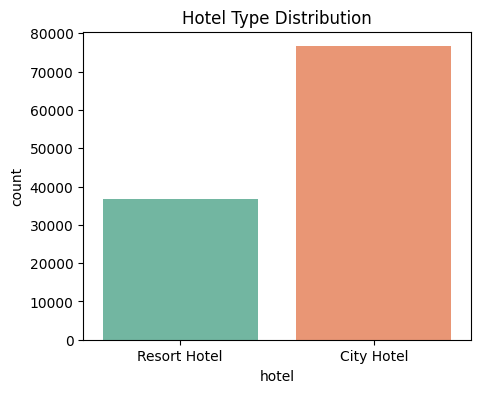

hotel
City Hotel      0.675
Resort Hotel    0.325
Name: proportion, dtype: float64


In [ ]:
#Univariate analysis
#2-10: checks the hotel type distribution
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='hotel', palette='Set2')
plt.title('Hotel Type Distribution')
plt.show()
print(f"{df['hotel'].value_counts(normalize=True).round(3)}")

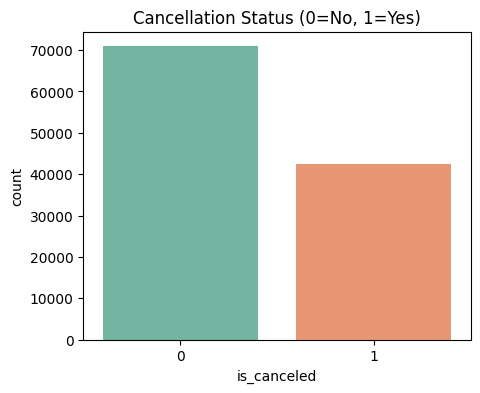

Cancellation Rate: 37.45%


In [ ]:
#2-11: checks the cancellation status
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='is_canceled', palette='Set2')
plt.title('Cancellation Status (0=No, 1=Yes)')
plt.show()
print(f"Cancellation Rate: {df['is_canceled'].mean():.2%}")

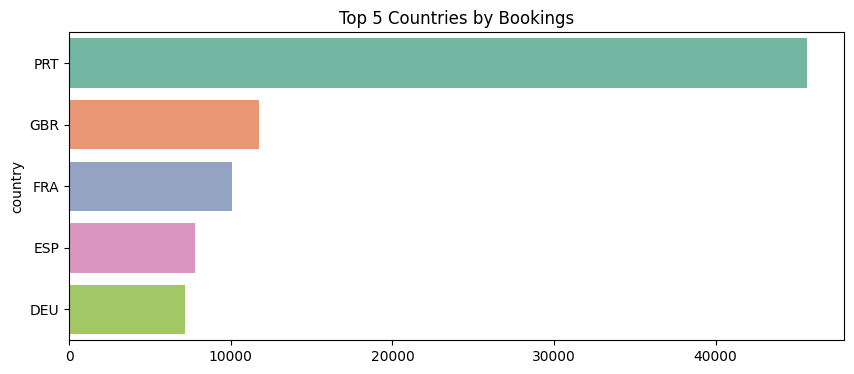

In [ ]:
#2-12: shows the top 5 countries
plt.figure(figsize=(10, 4))
top_5 = df['country'].value_counts().head(5)
sns.barplot(x=top_5.values, y=top_5.index, palette='Set2')
plt.title('Top 5 Countries by Bookings')
plt.show()

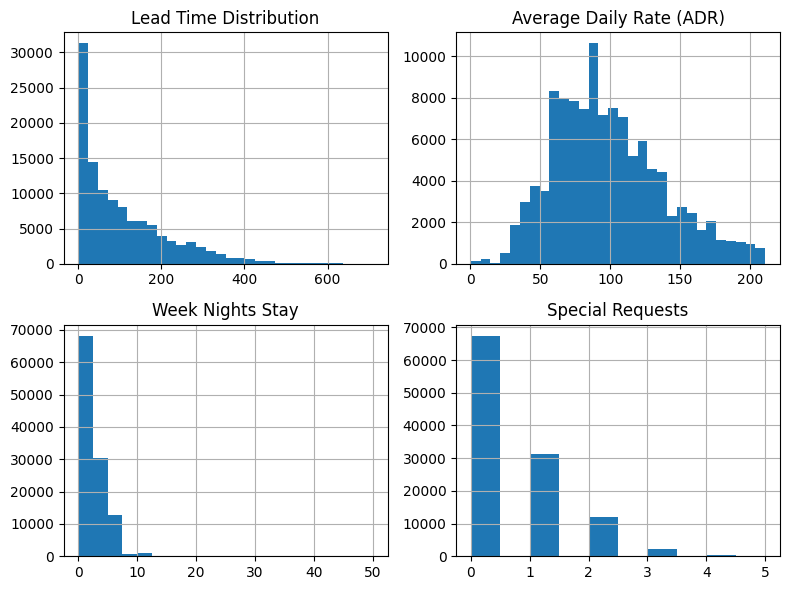

In [ ]:
#2-13: checks the key numerical variables
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
df['lead_time'].hist(ax=axes[0,0], bins=30)
axes[0,0].set_title('Lead Time Distribution')
df['adr'].hist(ax=axes[0,1], bins=30)
axes[0,1].set_title('Average Daily Rate (ADR)')
df['stays_in_week_nights'].hist(ax=axes[1,0], bins=20)
axes[1,0].set_title('Week Nights Stay')
df['total_of_special_requests'].hist(ax=axes[1,1], bins=10)
axes[1,1].set_title('Special Requests')
plt.tight_layout()
plt.show()

3. Relationship analysis

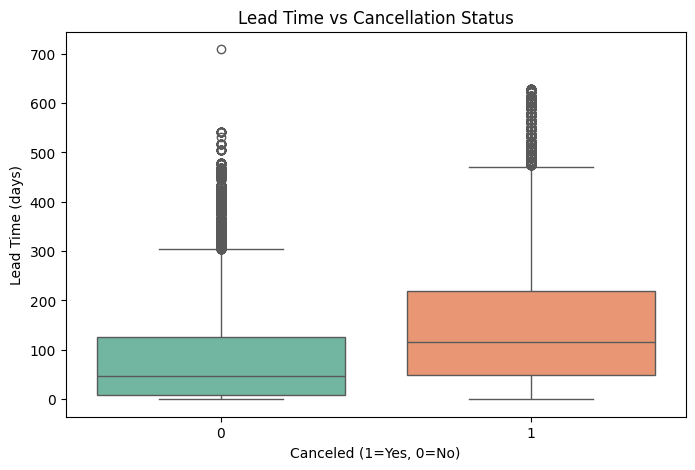

Average Lead Time: Not Canceled: 81.6 days Canceled: 147.1 days


In [ ]:
#2-14: Lead Time vs Cancellation
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='is_canceled', y='lead_time', palette='Set2')
plt.title('Lead Time vs Cancellation Status')
plt.xlabel('Canceled (1=Yes, 0=No)')
plt.ylabel('Lead Time (days)')
plt.show()
lead_time_stats = df.groupby('is_canceled')['lead_time'].mean()
print(f"Average Lead Time: Not Canceled: {lead_time_stats[0]:.1f} days Canceled: {lead_time_stats[1]:.1f} days")

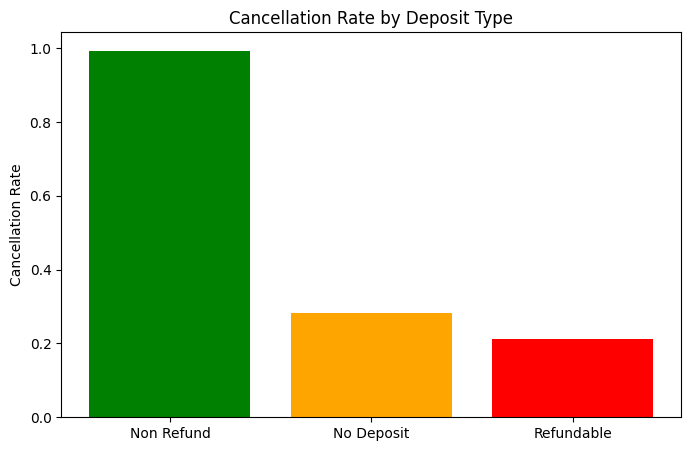

Cancellation Rate by Deposit Type:
  Non Refund: 99.37%
  No Deposit: 28.34%
  Refundable: 21.25%


In [ ]:
#2-15: Deposit Type vs Cancellation
plt.figure(figsize=(8, 5))
deposit_mapping = {0: 'No Deposit', 1: 'Refundable', 2: 'Non Refund'}
cancel_by_deposit = df.groupby('deposit_type_encoded')['is_canceled'].mean().sort_values(ascending=False)
labels = [deposit_mapping[x] for x in cancel_by_deposit.index]

plt.bar(labels, cancel_by_deposit.values, color=['green', 'orange', 'red'])
plt.title('Cancellation Rate by Deposit Type')
plt.ylabel('Cancellation Rate')
plt.xticks(rotation=0)
plt.show()

print(f"Cancellation Rate by Deposit Type:")
for deposit_code, rate in cancel_by_deposit.items():
    deposit_name = deposit_mapping[deposit_code]
    print(f"  {deposit_name}: {rate:.2%}")

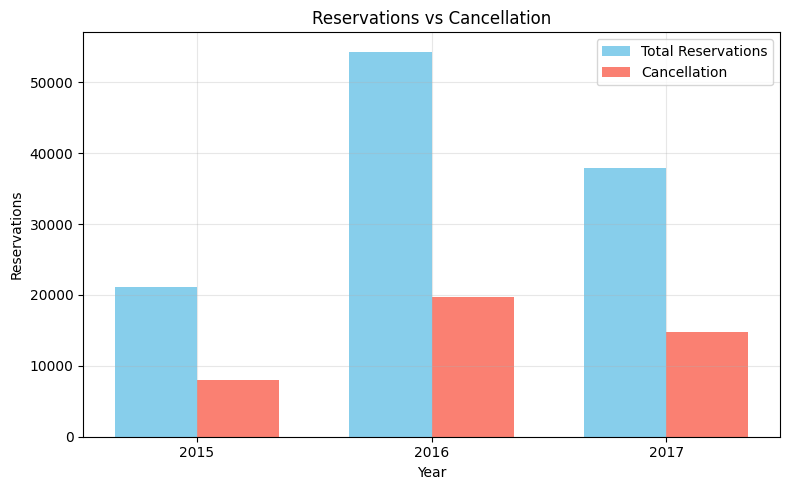

In [ ]:
#2-16: Reservation vs Cancellation
yearly_stats = df.groupby('arrival_date_year').agg(
    total_bookings = ('is_canceled', 'count'),
    canceled_bookings = ('is_canceled', 'sum')
).reset_index()
yearly_stats['cancellation_rate'] = (
    yearly_stats['canceled_bookings'] / yearly_stats['total_bookings'] * 100
)

plt.figure(figsize=(8, 5))
years = yearly_stats['arrival_date_year'].astype(str)
width = 0.35
x = range(len(years))
plt.bar(x, yearly_stats['total_bookings'], width, label='Total Reservations', color='skyblue')
plt.bar([i + width for i in x], yearly_stats['canceled_bookings'], width, label='Cancellation', color='salmon')
plt.xlabel('Year')
plt.ylabel('Reservations')
plt.title('Reservations vs Cancellation')
plt.xticks([i + width/2 for i in x], years)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

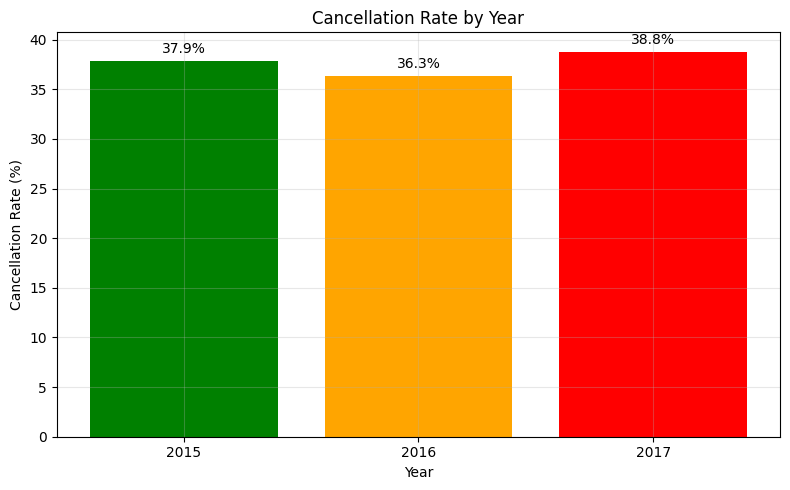

In [ ]:
#2-17: is the year affecting cancellations?
plt.figure(figsize=(8, 5))

bars = plt.bar(
    yearly_stats['arrival_date_year'].astype(str),
    yearly_stats['cancellation_rate'],
    color=['green', 'orange', 'red'][:len(yearly_stats)]  # safe if more/less years
)

plt.xlabel('Year')
plt.ylabel('Cancellation Rate (%)')
plt.title('Cancellation Rate by Year')
plt.grid(True, alpha=0.3)

# Add percentage values on top of bars
for bar, rate in zip(bars, yearly_stats['cancellation_rate']):
    plt.text(
        bar.get_x() + bar.get_width() / 2.,
        bar.get_height() + 0.5,
        f'{rate:.1f}%',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

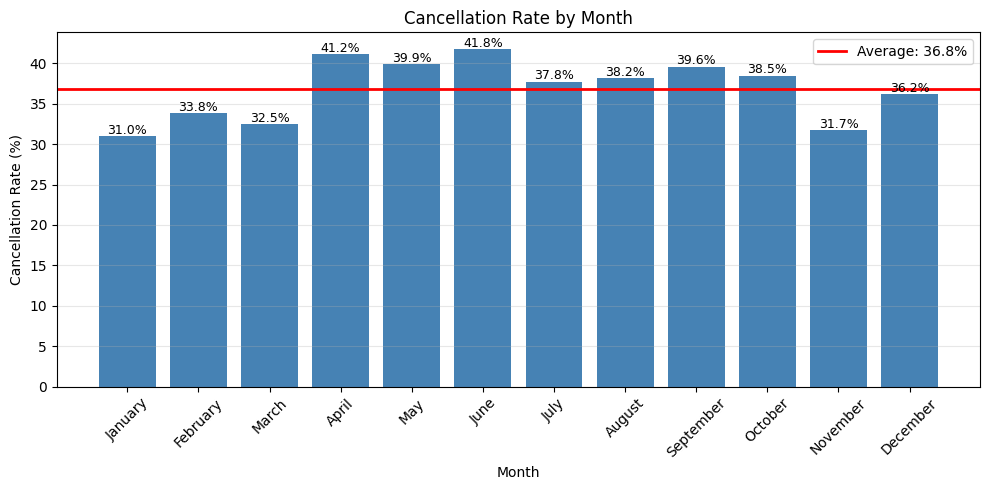

In [ ]:
#2-18: is the month affecting cancellations?
cancel_rate_by_month = df.groupby('arrival_month_num')['is_canceled'].mean() * 100
month_names = {1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June', 7: 'July', 8: 'August',
               9: 'September', 10: 'October', 11: 'November', 12: 'December'}

plt.figure(figsize=(10, 5))
bars = plt.bar([month_names.get(m, m) for m in cancel_rate_by_month.index],
               cancel_rate_by_month.values, color='steelblue')
plt.xlabel('Month')
plt.ylabel('Cancellation Rate (%)')
plt.title('Cancellation Rate by Month')
plt.xticks(rotation=45)

# Add percentage values on bars
for bar, rate in zip(bars, cancel_rate_by_month.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{rate:.1f}%', ha='center', fontsize=9)

plt.axhline(y=cancel_rate_by_month.mean(), color='red', linestyle='-',
            linewidth=2, label=f'Average: {cancel_rate_by_month.mean():.1f}%')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

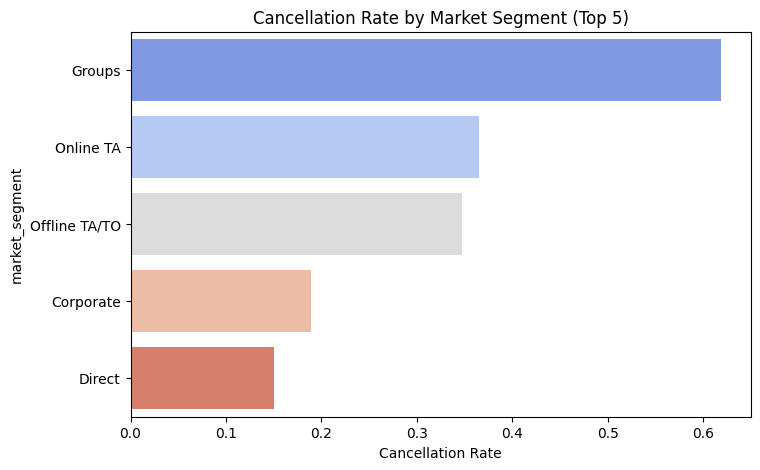

In [ ]:
#2-19: Market Segment vs Cancellation (Top 5 segments)
plt.figure(figsize=(8, 5))
top_segments = df['market_segment'].value_counts().head(5).index
segment_data = df[df['market_segment'].isin(top_segments)]
segment_cancel = segment_data.groupby('market_segment')['is_canceled'].mean().sort_values(ascending=False)

sns.barplot(x=segment_cancel.values, y=segment_cancel.index, palette='coolwarm')
plt.title('Cancellation Rate by Market Segment (Top 5)')
plt.xlabel('Cancellation Rate')
plt.show()

In [ ]:
#Multivariate analysis
#2-20: simple correlation with target
print("\nCorrelation with Cancellation:")
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = [col for col in numeric_cols if col != 'is_canceled']
correlations = df[numeric_cols].corrwith(df['is_canceled'])
print("\nTop 10 POSITIVE correlations (increase cancellation):")
print(correlations.sort_values(ascending=False).head(10).round(3))
print("\nTop 10 NEGATIVE correlations (decrease cancellation):")
print(correlations.sort_values(ascending=False).tail(10).round(3))


Correlation with Cancellation:

Top 10 POSITIVE correlations (increase cancellation):
deposit_type_encoded      0.490
lead_time                 0.294
previous_cancellations    0.112
adults                    0.060
days_in_waiting_list      0.056
total_people              0.042
adr                       0.036
stays_in_week_nights      0.015
arrival_month_num         0.013
arrival_date_year         0.011
dtype: float64

Top 10 NEGATIVE correlations (decrease cancellation):
children                         -0.001
arrival_date_day_of_month        -0.007
stays_in_weekend_nights          -0.011
babies                           -0.031
previous_bookings_not_canceled   -0.055
is_repeated_guest                -0.075
booking_changes                  -0.144
required_car_parking_spaces      -0.193
total_of_special_requests        -0.236
room_type_changed                -0.246
dtype: float64


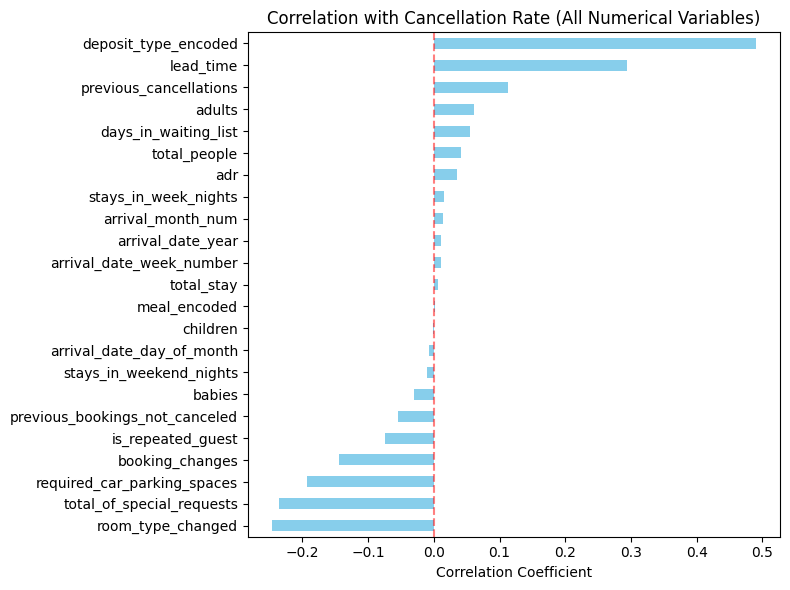

In [ ]:
#2-21: simple correlation with target vizualisation
plt.figure(figsize=(8, 6))
correlations.sort_values().plot(kind='barh', color='skyblue')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
plt.title('Correlation with Cancellation Rate (All Numerical Variables)')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

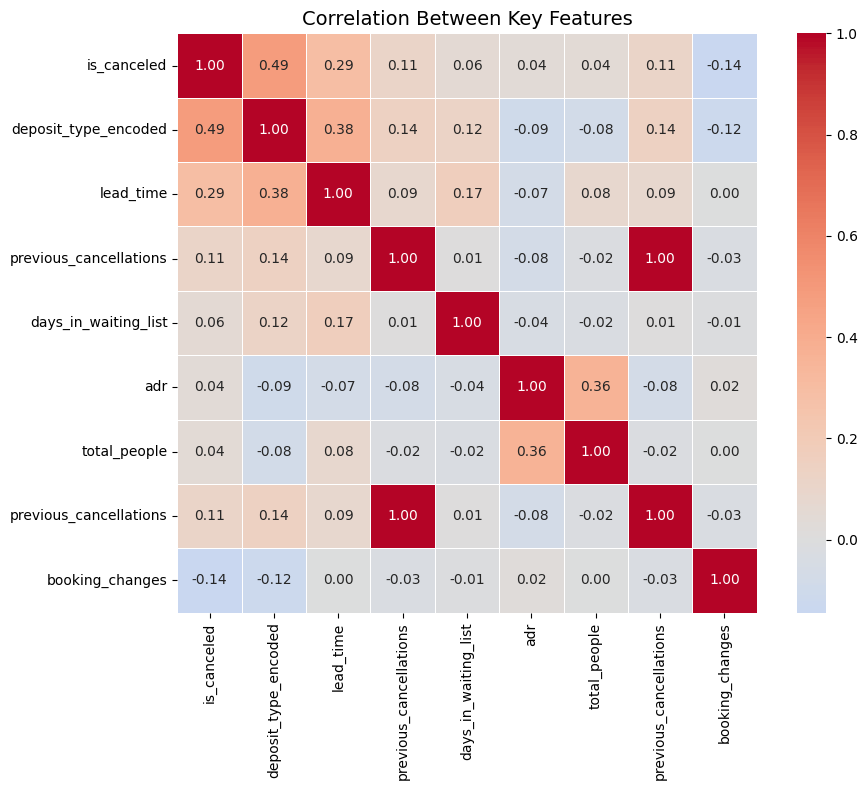

In [ ]:
#2-22: correlation heatmap

key_features = ['is_canceled',
                'deposit_type_encoded',
                'lead_time',
                'previous_cancellations',
                'days_in_waiting_list',
                'adr',
                'total_people',
                'previous_cancellations',
                'booking_changes']

plt.figure(figsize=(10, 8))
corr_matrix = df[key_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=0.5, square=True)
plt.title('Correlation Between Key Features', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
#3-16: variables requiring one-hot encoding
one_hot_cols = ['hotel', 'market_segment', 'customer_type', 'reserved_room_type']

# Use pandas get_dummies
df_encoded = pd.get_dummies(df, columns=one_hot_cols, drop_first=True)

In [ ]:
#2-23: separates variables into categorical and numerical groups
categorical_cols = ['hotel',
                    'country',
                    'market_segment',
                    'distribution_channel',
                    'reserved_room_type',
                    'assigned_room_type',
                    'customer_type',
                    'reservation_status',
                    'reservation_status_date']

numerical_cols = ['is_canceled',
                  'lead_time',
                  'arrival_date_year',
                  'arrival_date_week_number',
                  'arrival_date_day_of_month',
                  'stays_in_weekend_nights',
                  'stays_in_week_nights',
                  'adults',
                  'children',
                  'babies',
                  'is_repeated_guest',
                  'previous_cancellations',
                  'previous_bookings_not_canceled',
                  'booking_changes',
                  'days_in_waiting_list',
                  'adr',
                  'required_car_parking_spaces',
                  'total_of_special_requests',
                  'total_stay',
                  'total_people',
                  'room_type_changed',
                  'arrival_month_num',
                  'meal_encoded',
                  'deposit_type_encoded']

4. Iterative Process

In [ ]:
#4-1 data preparation
print("="*70)
print("DATA PREPARATION AND PREPROCESSING")
print("="*70)

# Function to encode categorical variables
def encode_categorical(df, categorical_cols):
    """
    Encode categorical variables using LabelEncoder

    Parameters:
    -----------
    df : pandas DataFrame
        Input dataframe
    categorical_cols : list
        List of categorical column names

    Returns:
    --------
    df_encoded : pandas DataFrame
        Encoded dataframe
    label_encoders : dict
        Dictionary of label encoders for each column
    """
    df_encoded = df.copy()
    label_encoders = {}

    for col in categorical_cols:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
        label_encoders[col] = le

    return df_encoded, label_encoders

# List of categorical columns to encode
categorical_cols = ['hotel', 'arrival_month_num', 'meal_encoded', 'country',
                    'market_segment', 'distribution_channel',
                    'reserved_room_type', 'assigned_room_type',
                    'deposit_type_encoded', 'customer_type']

# Apply encoding
df_encoded, label_encoders = encode_categorical(df, categorical_cols)

# Separate features and target
X = df_encoded.drop(['is_canceled', 'reservation_status', 'reservation_status_date'], axis=1)
y = df_encoded['is_canceled']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize features (important for distance-based algorithms like KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Display data information
print(f"\nDataset Information:")
print(f"-"*40)
print(f"Training set shape: {X_train_scaled.shape}")
print(f"Testing set shape: {X_test_scaled.shape}")
print(f"Features: {X_train.shape[1]}")
print(f"Cancellation rate (train): {y_train.mean():.2%}")
print(f"Cancellation rate (test): {y_test.mean():.2%}")
print(f"Class distribution (train):")
print(f"  Not canceled (0): {(y_train == 0).sum()} samples")
print(f"  Canceled (1): {(y_train == 1).sum()} samples")

DATA PREPARATION AND PREPROCESSING

Dataset Information:
----------------------------------------
Training set shape: (90711, 30)
Testing set shape: (22678, 30)
Features: 30
Cancellation rate (train): 37.45%
Cancellation rate (test): 37.45%
Class distribution (train):
  Not canceled (0): 56743 samples
  Canceled (1): 33968 samples


In [ ]:
#4-2: model evatualtion function
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, show_confusion_matrix=True):
    """
    Evaluate a classification model with comprehensive metrics

    Parameters:
    -----------
    model : sklearn estimator
        Classification model
    X_train, X_test : array-like
        Training and testing features
    y_train, y_test : array-like
        Training and testing labels
    model_name : str
        Name of the model for display
    show_confusion_matrix : bool
        Whether to display confusion matrix

    Returns:
    --------
    result_dict : dict
        Dictionary containing evaluation results
    """

    # Train model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None

    # Cross-validation scores
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

    # Display results
    print(f"\n{'='*60}")
    print(f"MODEL: {model_name}")
    print(f"{'='*60}")
    print(f"Accuracy: {accuracy:.4f}")
    if roc_auc is not None:
        print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"Cross-validation Accuracy (5 folds): {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

    # Display classification report
    print(f"\nClassification Report:")
    print(f"-"*40)
    print(classification_report(y_test, y_pred, target_names=['Not Canceled', 'Canceled']))

    # Display confusion matrix
    if show_confusion_matrix:
        print(f"\nConfusion Matrix:")
        print(f"-"*40)

        # Create formatted confusion matrix display
        conf_matrix_df = pd.DataFrame(conf_matrix,
                                      index=['Actual Not Canceled', 'Actual Canceled'],
                                      columns=['Predicted Not Canceled', 'Predicted Canceled'])
        print(conf_matrix_df)
        print()

        # Calculate additional metrics from confusion matrix
        TN, FP, FN, TP = conf_matrix.ravel()
        print(f"True Negatives (TN): {TN} - Correctly predicted not canceled")
        print(f"False Positives (FP): {FP} - Incorrectly predicted as canceled")
        print(f"False Negatives (FN): {FN} - Incorrectly predicted as not canceled")
        print(f"True Positives (TP): {TP} - Correctly predicted canceled")
        print(f"Sensitivity (Recall): {TP/(TP+FN):.4f} - Ability to detect cancellations")
        print(f"Specificity: {TN/(TN+FP):.4f} - Ability to detect non-cancellations")
        print(f"Precision: {TP/(TP+FP):.4f} - Accuracy of positive predictions")

        # Visualization of confusion matrix
        plt.figure(figsize=(8, 6))
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Not Canceled', 'Canceled'],
                    yticklabels=['Not Canceled', 'Canceled'])
        plt.title(f'Confusion Matrix - {model_name}', fontsize=14, fontweight='bold')
        plt.ylabel('Actual', fontsize=12)
        plt.xlabel('Predicted', fontsize=12)
        plt.tight_layout()
        plt.show()

    return {
        'model_name': model_name,
        'model': model,
        'accuracy': accuracy,
        'roc_auc': roc_auc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'conf_matrix': conf_matrix,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'TN': TN if show_confusion_matrix else None,
        'FP': FP if show_confusion_matrix else None,
        'FN': FN if show_confusion_matrix else None,
        'TP': TP if show_confusion_matrix else None
    }

In [ ]:
#4-3: List to store all results
all_results = []


MODEL: Dummy Classifier (Stratified)
Accuracy: 0.5319
ROC-AUC: 0.5004
Cross-validation Accuracy (5 folds): 0.5340 (+/- 0.0057)

Classification Report:
----------------------------------------
              precision    recall  f1-score   support

Not Canceled       0.63      0.63      0.63     14186
    Canceled       0.37      0.37      0.37      8492

    accuracy                           0.53     22678
   macro avg       0.50      0.50      0.50     22678
weighted avg       0.53      0.53      0.53     22678


Confusion Matrix:
----------------------------------------
                     Predicted Not Canceled  Predicted Canceled
Actual Not Canceled                    8879                5307
Actual Canceled                        5309                3183

True Negatives (TN): 8879 - Correctly predicted not canceled
False Positives (FP): 5307 - Incorrectly predicted as canceled
False Negatives (FN): 5309 - Incorrectly predicted as not canceled
True Positives (TP): 3183 - Correctl

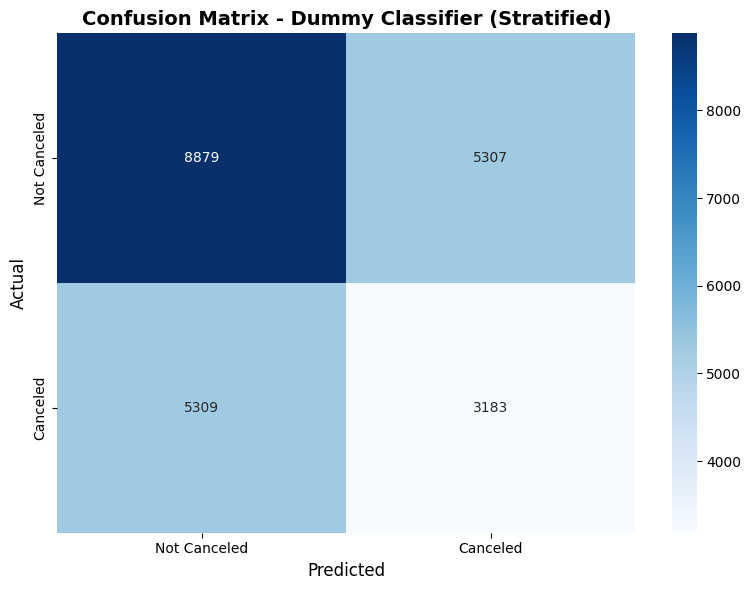

In [ ]:
#4-4 Dummy Classifier (Baseline Model)
dummy_clf = DummyClassifier(strategy='stratified', random_state=42)
dummy_result = evaluate_model(dummy_clf, X_train_scaled, X_test_scaled, y_train, y_test,
                               "Dummy Classifier (Stratified)")
all_results.append(dummy_result)


MODEL: Logistic Regression
Accuracy: 0.7977
ROC-AUC: 0.8728
Cross-validation Accuracy (5 folds): 0.7992 (+/- 0.0049)

Classification Report:
----------------------------------------
              precision    recall  f1-score   support

Not Canceled       0.79      0.92      0.85     14186
    Canceled       0.82      0.59      0.69      8492

    accuracy                           0.80     22678
   macro avg       0.80      0.76      0.77     22678
weighted avg       0.80      0.80      0.79     22678


Confusion Matrix:
----------------------------------------
                     Predicted Not Canceled  Predicted Canceled
Actual Not Canceled                   13068                1118
Actual Canceled                        3470                5022

True Negatives (TN): 13068 - Correctly predicted not canceled
False Positives (FP): 1118 - Incorrectly predicted as canceled
False Negatives (FN): 3470 - Incorrectly predicted as not canceled
True Positives (TP): 5022 - Correctly predict

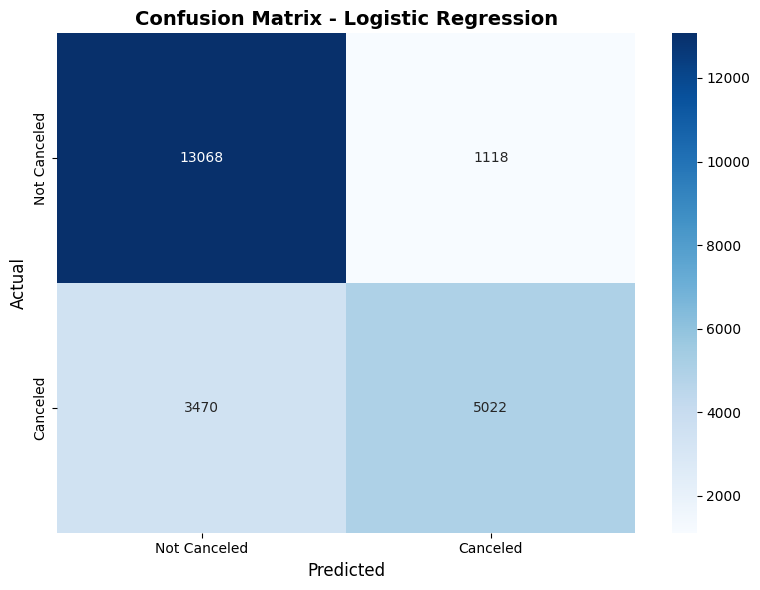

In [ ]:
#4-5: Logistic Regression
log_reg = LogisticRegression(random_state=42, max_iter=1000, C=1.0, penalty='l2', solver='liblinear')
log_reg_result = evaluate_model(log_reg, X_train_scaled, X_test_scaled, y_train, y_test,
                                 "Logistic Regression")
all_results.append(log_reg_result)


MODEL: Naive Bayes (Gaussian)
Accuracy: 0.5528
ROC-AUC: 0.8207
Cross-validation Accuracy (5 folds): 0.5489 (+/- 0.0037)

Classification Report:
----------------------------------------
              precision    recall  f1-score   support

Not Canceled       0.94      0.31      0.46     14186
    Canceled       0.45      0.97      0.62      8492

    accuracy                           0.55     22678
   macro avg       0.70      0.64      0.54     22678
weighted avg       0.76      0.55      0.52     22678


Confusion Matrix:
----------------------------------------
                     Predicted Not Canceled  Predicted Canceled
Actual Not Canceled                    4340                9846
Actual Canceled                         296                8196

True Negatives (TN): 4340 - Correctly predicted not canceled
False Positives (FP): 9846 - Incorrectly predicted as canceled
False Negatives (FN): 296 - Incorrectly predicted as not canceled
True Positives (TP): 8196 - Correctly predic

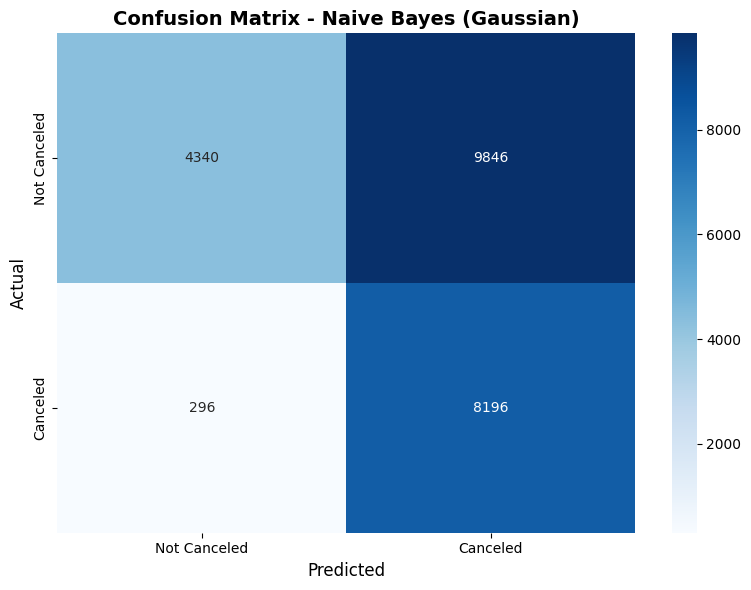

In [ ]:
#4-6: Naive Bayes
nb_clf = GaussianNB()
nb_result = evaluate_model(nb_clf, X_train_scaled, X_test_scaled, y_train, y_test,
                            "Naive Bayes (Gaussian)")
all_results.append(nb_result)


MODEL: K-Nearest Neighbors (k=5)
Accuracy: 0.8367
ROC-AUC: 0.9044
Cross-validation Accuracy (5 folds): 0.8323 (+/- 0.0067)

Classification Report:
----------------------------------------
              precision    recall  f1-score   support

Not Canceled       0.86      0.89      0.87     14186
    Canceled       0.80      0.75      0.78      8492

    accuracy                           0.84     22678
   macro avg       0.83      0.82      0.82     22678
weighted avg       0.84      0.84      0.84     22678


Confusion Matrix:
----------------------------------------
                     Predicted Not Canceled  Predicted Canceled
Actual Not Canceled                   12563                1623
Actual Canceled                        2081                6411

True Negatives (TN): 12563 - Correctly predicted not canceled
False Positives (FP): 1623 - Incorrectly predicted as canceled
False Negatives (FN): 2081 - Incorrectly predicted as not canceled
True Positives (TP): 6411 - Correctly p

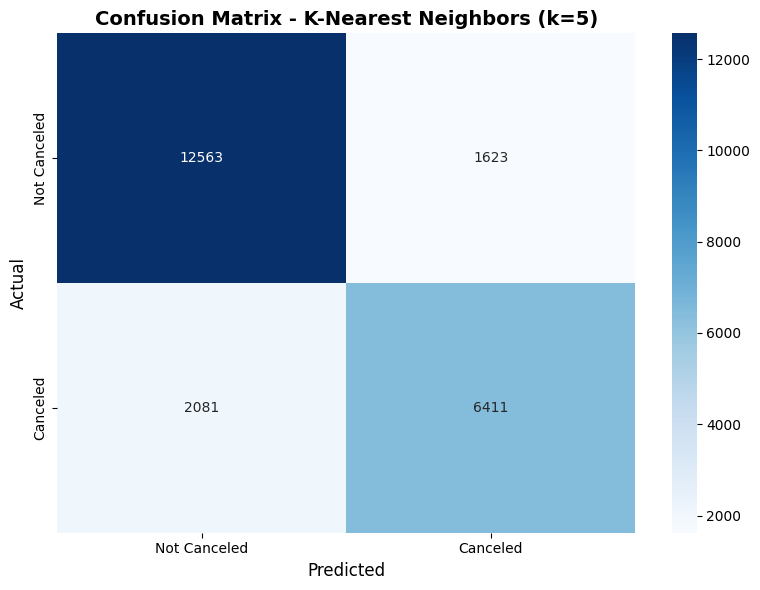

In [ ]:
#4-7: K-Nearest Neighbors

knn_clf = KNeighborsClassifier(n_neighbors=5, weights='uniform', metric='euclidean')
knn_result = evaluate_model(knn_clf, X_train_scaled, X_test_scaled, y_train, y_test,
                             "K-Nearest Neighbors (k=5)")
all_results.append(knn_result)


MODEL: Decision Tree
Accuracy: 0.8485
ROC-AUC: 0.9191
Cross-validation Accuracy (5 folds): 0.8424 (+/- 0.0071)

Classification Report:
----------------------------------------
              precision    recall  f1-score   support

Not Canceled       0.86      0.90      0.88     14186
    Canceled       0.82      0.76      0.79      8492

    accuracy                           0.85     22678
   macro avg       0.84      0.83      0.84     22678
weighted avg       0.85      0.85      0.85     22678


Confusion Matrix:
----------------------------------------
                     Predicted Not Canceled  Predicted Canceled
Actual Not Canceled                   12804                1382
Actual Canceled                        2053                6439

True Negatives (TN): 12804 - Correctly predicted not canceled
False Positives (FP): 1382 - Incorrectly predicted as canceled
False Negatives (FN): 2053 - Incorrectly predicted as not canceled
True Positives (TP): 6439 - Correctly predicted can

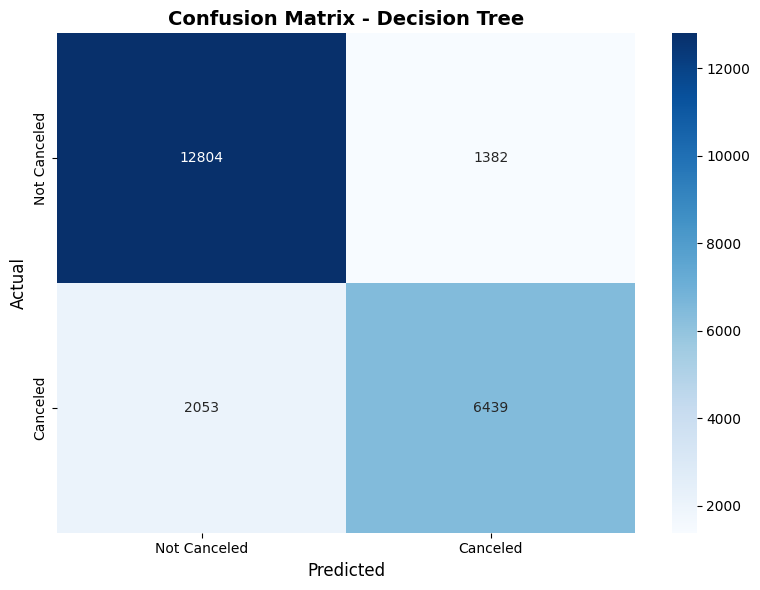

In [ ]:
#4-8: Decision Tree
dt_clf = DecisionTreeClassifier(random_state=42, max_depth=10, min_samples_split=5,
                                 min_samples_leaf=2, criterion='gini')
dt_result = evaluate_model(dt_clf, X_train_scaled, X_test_scaled, y_train, y_test,
                            "Decision Tree")
all_results.append(dt_result)


MODEL: Random Forest
Accuracy: 0.8805
ROC-AUC: 0.9520
Cross-validation Accuracy (5 folds): 0.8784 (+/- 0.0078)

Classification Report:
----------------------------------------
              precision    recall  f1-score   support

Not Canceled       0.88      0.94      0.91     14186
    Canceled       0.88      0.78      0.83      8492

    accuracy                           0.88     22678
   macro avg       0.88      0.86      0.87     22678
weighted avg       0.88      0.88      0.88     22678


Confusion Matrix:
----------------------------------------
                     Predicted Not Canceled  Predicted Canceled
Actual Not Canceled                   13309                 877
Actual Canceled                        1834                6658

True Negatives (TN): 13309 - Correctly predicted not canceled
False Positives (FP): 877 - Incorrectly predicted as canceled
False Negatives (FN): 1834 - Incorrectly predicted as not canceled
True Positives (TP): 6658 - Correctly predicted canc

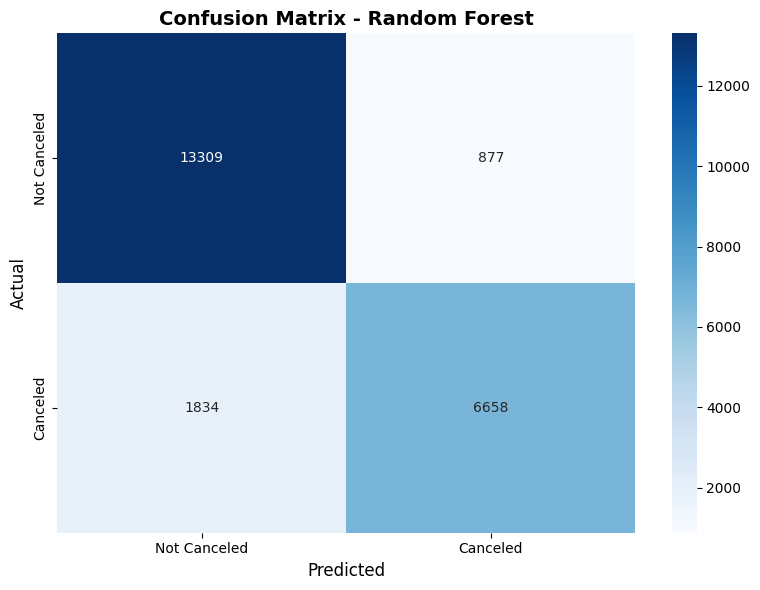

In [ ]:
#4-9: Random Forest
rf_clf = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=20,
                                 min_samples_split=5, min_samples_leaf=2, n_jobs=-1)
rf_result = evaluate_model(rf_clf, X_train_scaled, X_test_scaled, y_train, y_test,
                            "Random Forest")
all_results.append(rf_result)


MODEL PERFORMANCE COMPARISON - ALL MODELS

📊 PERFORMANCE COMPARISON TABLE:
----------------------------------------------------------------------
                        Model Accuracy ROC-AUC CV Accuracy Sensitivity Specificity Precision
Dummy Classifier (Stratified)   0.5319  0.5004      0.5340      0.3748      0.6259    0.3749
          Logistic Regression   0.7977  0.8728      0.7992      0.5914      0.9212    0.8179
       Naive Bayes (Gaussian)   0.5528  0.8207      0.5489      0.9651      0.3059    0.4543
    K-Nearest Neighbors (k=5)   0.8367  0.9044      0.8323      0.7549      0.8856    0.7980
                Decision Tree   0.8485  0.9191      0.8424      0.7582      0.9026    0.8233
                Random Forest   0.8805  0.9520      0.8784      0.7840      0.9382    0.8836


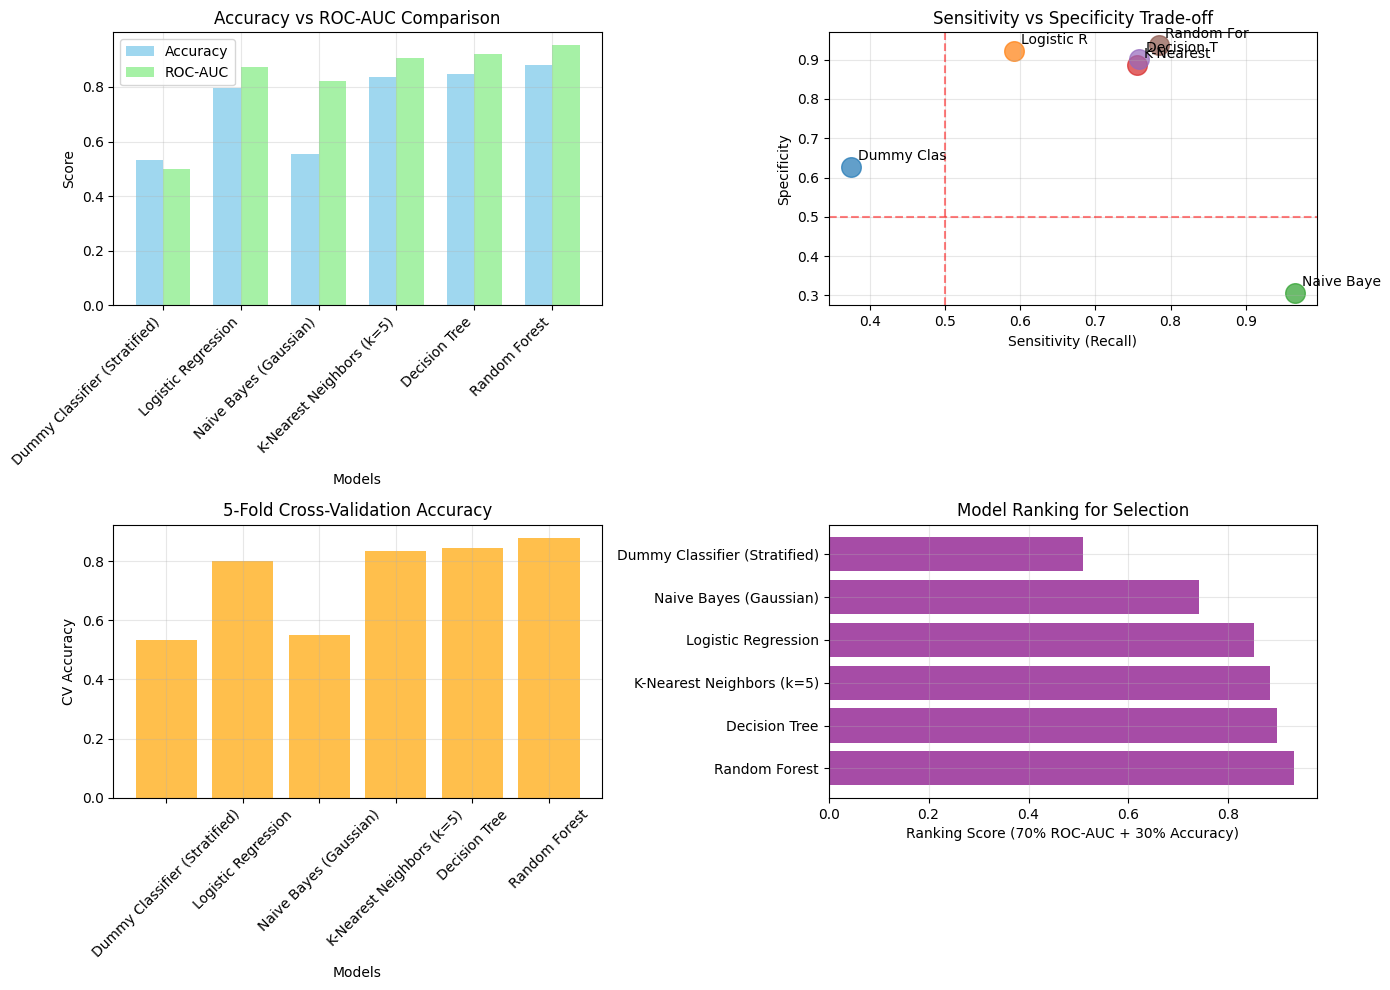

In [ ]:
#4-10: MODEL COMPARISON AND SELECTION (Part of Iterative Process)

print("\n" + "="*70)
print("MODEL PERFORMANCE COMPARISON - ALL MODELS")
print("="*70)

# Create comprehensive comparison dataframe
comparison_data = []
for result in all_results:
    # Calculate additional metrics
    if result['TN'] is not None:
        sensitivity = result['TP'] / (result['TP'] + result['FN']) if (result['TP'] + result['FN']) > 0 else 0
        specificity = result['TN'] / (result['TN'] + result['FP']) if (result['TN'] + result['FP']) > 0 else 0
        precision = result['TP'] / (result['TP'] + result['FP']) if (result['TP'] + result['FP']) > 0 else 0
    else:
        sensitivity = specificity = precision = None

    comparison_data.append({
        'Model': result['model_name'],
        'Accuracy': result['accuracy'],
        'ROC-AUC': result['roc_auc'] if result['roc_auc'] else 0,
        'CV Accuracy': result['cv_mean'],
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'Precision': precision
    })

comparison_df = pd.DataFrame(comparison_data)

# Display comparison table
print("\n📊 PERFORMANCE COMPARISON TABLE:")
print("-"*70)
display_df = comparison_df.copy()
display_df['Accuracy'] = display_df['Accuracy'].apply(lambda x: f"{x:.4f}")
display_df['ROC-AUC'] = display_df['ROC-AUC'].apply(lambda x: f"{x:.4f}" if x != 0 else "N/A")
display_df['CV Accuracy'] = display_df['CV Accuracy'].apply(lambda x: f"{x:.4f}")
display_df['Sensitivity'] = display_df['Sensitivity'].apply(lambda x: f"{x:.4f}" if x is not None else "N/A")
display_df['Specificity'] = display_df['Specificity'].apply(lambda x: f"{x:.4f}" if x is not None else "N/A")
display_df['Precision'] = display_df['Precision'].apply(lambda x: f"{x:.4f}" if x is not None else "N/A")

print(display_df.to_string(index=False))

# Visual comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Accuracy Comparison
models_list = comparison_df['Model'].tolist()
accuracy_scores = comparison_df['Accuracy'].tolist()
roc_scores = comparison_df['ROC-AUC'].tolist()

x = np.arange(len(models_list))
width = 0.35
axes[0,0].bar(x - width/2, accuracy_scores, width, label='Accuracy', color='skyblue', alpha=0.8)
axes[0,0].bar(x + width/2, roc_scores, width, label='ROC-AUC', color='lightgreen', alpha=0.8)
axes[0,0].set_xlabel('Models')
axes[0,0].set_ylabel('Score')
axes[0,0].set_title('Accuracy vs ROC-AUC Comparison')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(models_list, rotation=45, ha='right')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. Sensitivity vs Specificity
for i, row in comparison_df.iterrows():
    if row['Sensitivity'] is not None and row['Specificity'] is not None:
        axes[0,1].scatter(row['Sensitivity'], row['Specificity'], s=200, alpha=0.7, label=row['Model'])
        axes[0,1].annotate(row['Model'][:10], (row['Sensitivity'], row['Specificity']),
                          xytext=(5,5), textcoords='offset points')
axes[0,1].set_xlabel('Sensitivity (Recall)')
axes[0,1].set_ylabel('Specificity')
axes[0,1].set_title('Sensitivity vs Specificity Trade-off')
axes[0,1].grid(True, alpha=0.3)
axes[0,1].axvline(x=0.5, color='red', linestyle='--', alpha=0.5)
axes[0,1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5)

# 3. Cross-Validation Scores
cv_means = comparison_df['CV Accuracy'].tolist()
axes[1,0].bar(models_list, cv_means, color='orange', alpha=0.7)
axes[1,0].set_xlabel('Models')
axes[1,0].set_ylabel('CV Accuracy')
axes[1,0].set_title('5-Fold Cross-Validation Accuracy')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(True, alpha=0.3)

# 4. Model Ranking
# Rank by ROC-AUC (primary) and Accuracy (secondary)
comparison_df['Rank_Score'] = comparison_df['ROC-AUC'] * 0.7 + comparison_df['Accuracy'] * 0.3
comparison_df = comparison_df.sort_values('Rank_Score', ascending=False)

axes[1,1].barh(comparison_df['Model'], comparison_df['Rank_Score'], color='purple', alpha=0.7)
axes[1,1].set_xlabel('Ranking Score (70% ROC-AUC + 30% Accuracy)')
axes[1,1].set_title('Model Ranking for Selection')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

5. Final Model and Evaluation

In [ ]:
# 5-1: FINAL MODEL SELECTION (Part of Final Model)
print("\n" + "="*70)
print("🎯 FINAL MODEL SELECTION AND JUSTIFICATION")
print("="*70)

# Select best model based on multiple criteria
best_by_roc = comparison_df.iloc[comparison_df['ROC-AUC'].idxmax()]
best_by_accuracy = comparison_df.iloc[comparison_df['Accuracy'].idxmax()]
best_by_cv = comparison_df.iloc[comparison_df['CV Accuracy'].idxmax()]
best_by_rank = comparison_df.iloc[0]  # Already sorted by Rank_Score

print("\n🔍 ANALYSIS OF TOP PERFORMERS:")
print("-"*40)
print(f"Best by ROC-AUC: {best_by_roc['Model']} (ROC-AUC: {best_by_roc['ROC-AUC']:.4f})")
print(f"Best by Accuracy: {best_by_accuracy['Model']} (Accuracy: {best_by_accuracy['Accuracy']:.4f})")
print(f"Best by CV: {best_by_cv['Model']} (CV Accuracy: {best_by_cv['CV Accuracy']:.4f})")
print(f"Best by Combined Rank: {best_by_rank['Model']} (Rank Score: {best_by_rank['Rank_Score']:.4f})")

# Decision logic for final model selection
print("\n🤔 SELECTION CRITERIA:")
print("-"*40)
print("1. ROC-AUC is most important for imbalanced classification")
print("2. Cross-validation stability indicates generalization")
print("3. Business context: Better to flag potential cancellations (high sensitivity)")
print("4. Model interpretability for business stakeholders")

# Select final model (you can adjust this logic)
if best_by_roc['Model'] == best_by_rank['Model']:
    final_model_name = best_by_roc['Model']
    selection_reason = "Highest ROC-AUC and best combined ranking"
elif best_by_cv['Model'] == best_by_rank['Model']:
    final_model_name = best_by_cv['Model']
    selection_reason = "Best cross-validation stability and good ROC-AUC"
else:
    # Default to Random Forest if it's among top performers
    if 'Random Forest' in comparison_df.head(3)['Model'].values:
        final_model_name = 'Random Forest'
        selection_reason = "Balanced performance across all metrics and good interpretability"
    else:
        final_model_name = best_by_rank['Model']
        selection_reason = "Best overall performance based on combined ranking"

print(f"\n✅ SELECTED FINAL MODEL: {final_model_name}")
print(f"📋 REASON: {selection_reason}")

# Get the final model object
final_model_idx = [i for i, result in enumerate(all_results) if result['model_name'] == final_model_name][0]
final_model = all_results[final_model_idx]['model']
final_model_results = all_results[final_model_idx]


🎯 FINAL MODEL SELECTION AND JUSTIFICATION

🔍 ANALYSIS OF TOP PERFORMERS:
----------------------------------------
Best by ROC-AUC: Dummy Classifier (Stratified) (ROC-AUC: 0.5004)
Best by Accuracy: Dummy Classifier (Stratified) (Accuracy: 0.5319)
Best by CV: Dummy Classifier (Stratified) (CV Accuracy: 0.5340)
Best by Combined Rank: Random Forest (Rank Score: 0.9306)

🤔 SELECTION CRITERIA:
----------------------------------------
1. ROC-AUC is most important for imbalanced classification
2. Cross-validation stability indicates generalization
3. Business context: Better to flag potential cancellations (high sensitivity)
4. Model interpretability for business stakeholders

✅ SELECTED FINAL MODEL: Random Forest
📋 REASON: Balanced performance across all metrics and good interpretability



📊 FINAL MODEL COMPREHENSIVE EVALUATION

📈 FINAL MODEL PERFORMANCE ON TEST SET:
----------------------------------------
Accuracy: 0.8805
ROC-AUC: 0.9520
Cross-validation Accuracy: 0.8784 (±0.0039)

📋 DETAILED CLASSIFICATION REPORT:
----------------------------------------
              precision    recall  f1-score   support

Not Canceled     0.8789    0.9382    0.9076     14186
    Canceled     0.8836    0.7840    0.8308      8492

    accuracy                         0.8805     22678
   macro avg     0.8812    0.8611    0.8692     22678
weighted avg     0.8807    0.8805    0.8788     22678



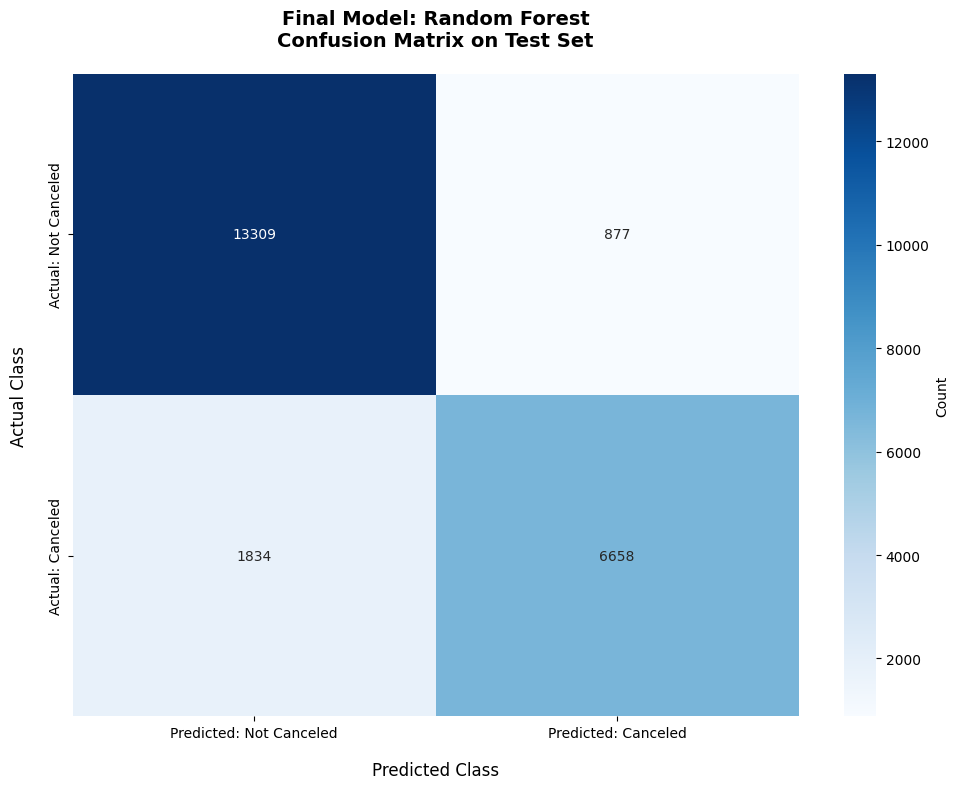

In [ ]:
#5-2: FINAL MODEL EVALUATION ON UNSEEN DATA

print("\n" + "="*70)
print("📊 FINAL MODEL COMPREHENSIVE EVALUATION")
print("="*70)

# Get predictions from final model
y_pred_final = final_model_results['y_pred']
y_pred_proba_final = final_model_results['y_pred_proba']

print(f"\n📈 FINAL MODEL PERFORMANCE ON TEST SET:")
print("-"*40)
print(f"Accuracy: {final_model_results['accuracy']:.4f}")
print(f"ROC-AUC: {final_model_results['roc_auc']:.4f}")
print(f"Cross-validation Accuracy: {final_model_results['cv_mean']:.4f} (±{final_model_results['cv_std']:.4f})")

# Detailed classification report
print(f"\n📋 DETAILED CLASSIFICATION REPORT:")
print("-"*40)
print(classification_report(y_test, y_pred_final,
                           target_names=['Not Canceled', 'Canceled'],
                           digits=4))

# Confusion matrix visualization
plt.figure(figsize=(10, 8))
cm = final_model_results['conf_matrix']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Not Canceled', 'Predicted: Canceled'],
            yticklabels=['Actual: Not Canceled', 'Actual: Canceled'],
            cbar_kws={'label': 'Count'})
plt.title(f'Final Model: {final_model_name}\nConfusion Matrix on Test Set',
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Actual Class', fontsize=12, labelpad=15)
plt.xlabel('Predicted Class', fontsize=12, labelpad=15)
plt.tight_layout()
plt.show()

In [ ]:
#5-3: BUSINESS APPLICATION EXAMPLE

print("\n" + "="*70)
print("BUSINESS APPLICATION AND DEPLOYMENT RECOMMENDATIONS")
print("="*70)

# Example: Predict for new bookings
print(f"\n🎫 EXAMPLE PREDICTIONS FOR NEW BOOKINGS:")
print("-"*40)

# Take 3 random samples from test set
np.random.seed(42)
sample_indices = np.random.choice(len(X_test_scaled), 3, replace=False)

for i, idx in enumerate(sample_indices):
    sample_features = X_test_scaled[idx:idx+1]
    actual_label = y_test.iloc[idx]
    prediction = final_model.predict(sample_features)[0]
    probability = final_model.predict_proba(sample_features)[0][1]

    print(f"\nBooking Example {i+1}:")
    print(f"  Actual Status: {'CANCELED' if actual_label == 1 else 'NOT CANCELED'}")
    print(f"  Predicted: {'WILL CANCEL' if prediction == 1 else 'WILL NOT CANCEL'}")
    print(f"  Cancellation Probability: {probability:.2%}")

    # Business recommendations based on probability
    if probability > 0.7:
        recommendation = "🔴 HIGH RISK - Require deposit or payment in advance"
    elif probability > 0.4:
        recommendation = "🟡 MEDIUM RISK - Send reminder emails, offer flexible options"
    else:
        recommendation = "🟢 LOW RISK - Standard booking process"

    print(f"  Recommendation: {recommendation}")  # FIXED: Changed 'recommendment' to 'recommendation'

# Threshold analysis for business decisions
print(f"\n📊 CANCELLATION RISK THRESHOLD ANALYSIS:")
print("-"*40)
thresholds = [0.3, 0.5, 0.7]
for threshold in thresholds:
    y_pred_threshold = (y_pred_proba_final > threshold).astype(int)
    accuracy_at_threshold = accuracy_score(y_test, y_pred_threshold)
    print(f"At threshold {threshold}: Accuracy = {accuracy_at_threshold:.4f}")

# Save the final model
import joblib
print(f"\n💾 SAVING FINAL MODEL:")
print("-"*40)
joblib.dump(final_model, f'final_model_{final_model_name.replace(" ", "_")}.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')
print(f"✓ Model saved as: final_model_{final_model_name.replace(' ', '_')}.pkl")
print(f"✓ Scaler saved as: scaler.pkl")
print(f"✓ Label encoders saved as: label_encoders.pkl")

# Final summary
print(f"\n" + "="*70)
print("✅ PROJECT COMPLETION SUMMARY")
print("="*70)
print(f"\n🎯 Problem: Predict hotel booking cancellations")
print(f"📊 Dataset: {df.shape[0]:,} bookings with {df.shape[1]} features")
print(f"🤖 Final Model: {final_model_name}")
print(f"📈 Performance: {final_model_results['accuracy']:.2%} accuracy, "
      f"{final_model_results['roc_auc']:.4f} ROC-AUC")
print(f"💡 Key Insight: Model can predict cancellations with good accuracy, "
      f"enabling proactive interventions")
print(f"\n" + "="*70)


BUSINESS APPLICATION AND DEPLOYMENT RECOMMENDATIONS

🎫 EXAMPLE PREDICTIONS FOR NEW BOOKINGS:
----------------------------------------

Booking Example 1:
  Actual Status: CANCELED
  Predicted: WILL CANCEL
  Cancellation Probability: 89.79%
  Recommendation: 🔴 HIGH RISK - Require deposit or payment in advance

Booking Example 2:
  Actual Status: NOT CANCELED
  Predicted: WILL NOT CANCEL
  Cancellation Probability: 26.11%
  Recommendation: 🟢 LOW RISK - Standard booking process

Booking Example 3:
  Actual Status: CANCELED
  Predicted: WILL CANCEL
  Cancellation Probability: 95.14%
  Recommendation: 🔴 HIGH RISK - Require deposit or payment in advance

📊 CANCELLATION RISK THRESHOLD ANALYSIS:
----------------------------------------
At threshold 0.3: Accuracy = 0.8531
At threshold 0.5: Accuracy = 0.8805
At threshold 0.7: Accuracy = 0.8460

💾 SAVING FINAL MODEL:
----------------------------------------
✓ Model saved as: final_model_Random_Forest.pkl
✓ Scaler saved as: scaler.pkl
✓ Label enc